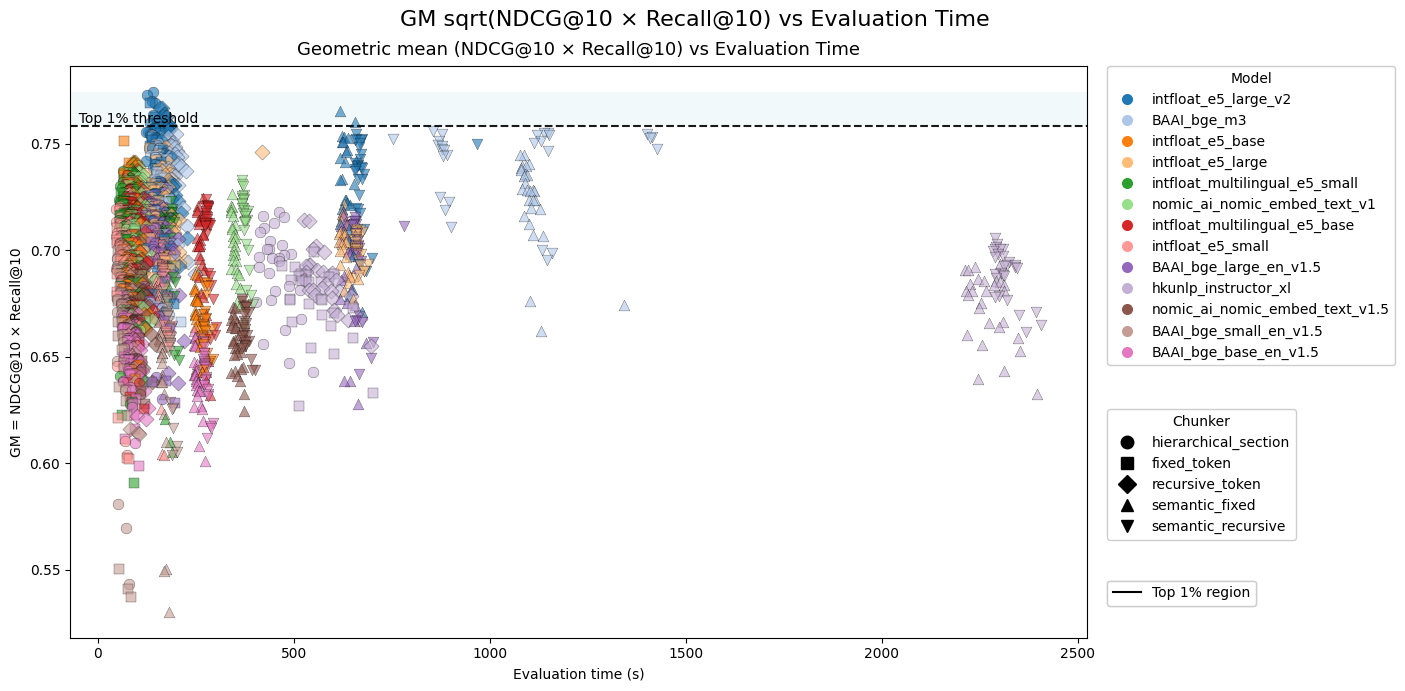


Top 1% configurations by geometric mean (GM = ndcg_at_10 × recall_at_10, threshold=0.7583; minimize duration_sum_s):
- model=intfloat_e5_large_v2 | chunker=hierarchical_section | size=384 | overlap=16 | GM=0.7743 | ndcg_at_10=0.6693 | recall_at_10=0.8958 | time=142.00s
- model=intfloat_e5_large_v2 | chunker=hierarchical_section | size=512 | overlap=0 | GM=0.7729 | ndcg_at_10=0.6651 | recall_at_10=0.8981 | time=125.00s
- model=intfloat_e5_large_v2 | chunker=hierarchical_section | size=448 | overlap=16 | GM=0.7699 | ndcg_at_10=0.6630 | recall_at_10=0.8939 | time=138.00s
- model=intfloat_e5_large_v2 | chunker=hierarchical_section | size=384 | overlap=32 | GM=0.7692 | ndcg_at_10=0.6633 | recall_at_10=0.8922 | time=145.00s
- model=intfloat_e5_large_v2 | chunker=fixed_token | size=512 | overlap=0 | GM=0.7691 | ndcg_at_10=0.6674 | recall_at_10=0.8863 | time=132.00s
- model=intfloat_e5_large_v2 | chunker=recursive_token | size=448 | overlap=0 | GM=0.7670 | ndcg_at_10=0.6628 | recall_at_10=0.8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# =======================
# CONFIG
# =======================
csv_path = "../artifacts/tests/combined.csv"

# Threshold for "top" configs by GM (as a fraction of items)
top_fraction = 0.01            # e.g., 0.10 => top 10%, 0.05 => top 5%

# Time axis (X) display
percentile_clip = None         # e.g., (0.02, 0.98) to clip extremes by percentiles

# Visual tweaks
alpha_points = 0.6             # opacity for all points
inner_point_size = 60          # inner filled point size
figsize = (14, 7)              # overall figure size

# =======================
# 1) Load
# =======================
df = pd.read_csv(csv_path)

# =======================
# 2) Resolve column names (robust to variations)
# =======================
aliases = {
    "ndcg@10":        ["ndcg@10", "ndcg_at_10"],
    "recall@10":      ["recall@10", "recall_at_10"],
    "duration_sum_s": ["duration_sum_s"],
    "model_name":     ["model_name", "model"],
    "chunker_y":      ["chunker_y", "chunker", "chunker_name"],
    "size":           ["size"],
    "overlap_y":      ["overlap_y", "overlap"],
}

def resolve_col(key):
    for cand in aliases[key]:
        if cand in df.columns:
            return cand
    raise KeyError(f"Missing required column for '{key}'. Looked for: {aliases[key]}")

col_ndcg   = resolve_col("ndcg@10")
col_recall = resolve_col("recall@10")
col_time   = resolve_col("duration_sum_s")
col_model  = resolve_col("model_name")
col_chunk  = next((c for c in aliases["chunker_y"] if c in df.columns), None)  # optional
col_size   = next((c for c in aliases["size"] if c in df.columns), None)       # optional
col_ovlp   = next((c for c in aliases["overlap_y"] if c in df.columns), None)  # optional

# =======================
# 3) Aesthetics: color by model, marker by chunker
# =======================
models = df[col_model].astype(str).unique()
if col_chunk:
    chunkers = df[col_chunk].astype(str).unique()
else:
    chunkers = np.array(["(none)"])

palette = plt.cm.tab20(np.linspace(0, 1, 20))
reps = int(np.ceil(len(models) / 20)) or 1
colors = np.vstack([palette for _ in range(reps)])[:len(models)]
model_color_map = {m: c for m, c in zip(models, colors)}

markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*', 'h', '8']
chunker_marker_map = {c: markers[i % len(markers)] for i, c in enumerate(chunkers)}

# =======================
# 4) Time column and optional clipping hints
# =======================
df["_time_sec"] = df[col_time].astype(float)

if percentile_clip:
    lo, hi = df["_time_sec"].quantile(list(percentile_clip))
    clip_min, clip_max = float(lo), float(hi)
else:
    clip_min = None
    clip_max = None

# =======================
# 5) Compute geometric mean (product) and configurable threshold
# =======================
df["_gm"] = np.sqrt(df[col_ndcg].astype(float) * df[col_recall].astype(float))  # product

top_fraction = max(0.0, min(1.0, float(top_fraction)))
q = 1.0 - top_fraction
gm_threshold = float(df["_gm"].quantile(q)) if len(df) else float("nan")

top_mask = df["_gm"] >= gm_threshold
top_df = df[top_mask].copy()

# =======================
# 6) Plot (single axis)
# =======================
fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=False, sharey=False)

# scatter all points
for _, r in df.iterrows():
    ax.scatter(
        r["_time_sec"], r["_gm"],
        c=[model_color_map[str(r[col_model])]],
        marker=chunker_marker_map.get(str(r[col_chunk]) if col_chunk else "(none)", 'o'),
        alpha=alpha_points, s=inner_point_size, edgecolors='k', linewidths=0.3
    )

# highlight region (instead of points)
if np.isfinite(gm_threshold):
    ax.axhspan(
        gm_threshold, df["_gm"].max(),
        facecolor='lightblue', alpha=0.15, label=f"Top {int(top_fraction*100)}% region",
        zorder=0
    )

    ax.axhline(gm_threshold, linestyle='--', linewidth=1.5, alpha=0.9, color='black')
    xmin = ax.get_xlim()[0]  # ✅ Use current axis min directly
    ax.text(
        xmin, gm_threshold, f"  Top {int(top_fraction*100)}% threshold",
        va="bottom", ha="left", fontsize=10
    )


# labels & scales
ax.set_title("Geometric mean (NDCG@10 × Recall@10) vs Evaluation Time", pad=8, fontsize=13)
ax.set_xlabel("Evaluation time (s)")
ax.set_ylabel("GM = NDCG@10 × Recall@10")


# optional vertical hints for percentile clipping
if clip_min is not None or clip_max is not None:
    if clip_min is not None:
        ax.axvline(clip_min, linestyle="--", linewidth=0.8, alpha=0.5, color="k")
    if clip_max is not None:
        ax.axvline(clip_max, linestyle="--", linewidth=0.8, alpha=0.5, color="k")

# Legends (outside, compact)
model_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=model_color_map[m], label=m, markersize=9)
    for m in models
]
chunker_handles = [
    Line2D([0], [0], marker=chunker_marker_map[c], color='black',
           linestyle='None', label=c, markersize=9)
    for c in chunkers
]
region_handle = Line2D([0], [0], linestyle='-', color='black',
                       label=f"Top {int(top_fraction*100)}% region")

leg1 = ax.legend(handles=model_handles, title="Model", loc='upper left',
                 bbox_to_anchor=(1.02, 1.0), borderaxespad=0., ncol=1, framealpha=0.95)
fig.add_artist(leg1)
leg2 = ax.legend(handles=chunker_handles, title="Chunker", loc='upper left',
                 bbox_to_anchor=(1.02, 0.4), borderaxespad=0., framealpha=0.95)
fig.add_artist(leg2)
leg3 = ax.legend(handles=[region_handle], loc='upper left',
                 bbox_to_anchor=(1.02, 0.1), borderaxespad=0., framealpha=0.95)
fig.add_artist(leg3)

plt.suptitle("GM sqrt(NDCG@10 × Recall@10) vs Evaluation Time", fontsize=16, y=0.98)
plt.tight_layout()
plt.subplots_adjust(right=0.78, top=0.90)
plt.show()

# =======================
# 7) Print Selected Table (Top X% by GM)
# =======================
def print_rows_top(label, rows):
    if rows is None or rows.empty:
        print(f"\n{label}: (none)")
        return
    print(f"\n{label} (GM = {col_ndcg} × {col_recall}, threshold={gm_threshold:.4f}; minimize {col_time}):")
    for _, r in rows.sort_values("_gm", ascending=False).iterrows():
        bits = [
            f"model={r[col_model]}",
            f"chunker={r[col_chunk]}" if col_chunk else None,
            f"size={r[col_size]}" if col_size else None,
            f"overlap={r[col_ovlp]}" if col_ovlp else None,
            f"GM={r['_gm']:.4f}",
            f"{col_ndcg}={r[col_ndcg]:.4f}",
            f"{col_recall}={r[col_recall]:.4f}",
            f"time={r[col_time]:.2f}s",
        ]
        print("- " + " | ".join(b for b in bits if b is not None))

print_rows_top(f"Top {int(top_fraction*100)}% configurations by geometric mean", top_df)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Conversion helper ---
def _safe_num(s):
    """Safely convert a series/column to numeric, coercing errors to NaN."""
    return pd.to_numeric(s, errors="coerce")

# --- Metric selection ---
def pick_metric(df, candidates):
    """Pick the first metric in candidates that exists in df, fallback to any RRF-like column."""
    for c in candidates:
        if c in df.columns:
            return c
    for col in df.columns:
        if "RRF" in col.upper():
            return col
    raise ValueError("No suitable primary metric found among candidates or df columns.")

def metric_title(df, metric):
    """Generate a title-friendly version of the metric name (can customize)."""
    return metric

# --- Save plot helper ---
def savefig(fig, name):
    """Save matplotlib figure to ../artifacts/ directory with nice defaults."""
    out = f"../artifacts/{name}.png"
    fig.savefig(out, bbox_inches="tight", dpi=200)
    print(f"✅ Saved: {out}")

# --- Metric direction inference ---
def infer_higher_better(metric_name, lower_is_better=None):
    """
    Decide whether a metric is higher-better or lower-better.
    - Uses the lower_is_better dict if provided.
    - Otherwise, uses keyword heuristics (cost, latency, duration, etc.).
    """
    if lower_is_better and metric_name in lower_is_better:
        return not lower_is_better[metric_name]

    low_keywords = ["latency", "duration", "time", "cost", "memory", "loss", "error"]
    return not any(k in metric_name.lower() for k in low_keywords)

# --- Normalization helper ---
def normalize_metric_column(df, metric_name, higher_better=True, sub_index=None):
    """
    Normalize a metric column in df to [0, 1].
    If sub_index is provided, normalize relative to the full df but return only sub rows.
    """
    series_full = _safe_num(df[metric_name])
    lo, hi = np.nanmin(series_full.values), np.nanmax(series_full.values)
    rng = hi - lo

    if sub_index is not None:
        series_sub = _safe_num(df.loc[sub_index, metric_name])
    else:
        series_sub = _safe_num(df[metric_name])

    if not np.isfinite(lo) or not np.isfinite(hi) or rng <= 0:
        vals = pd.Series(0.5, index=series_sub.index)  # degenerate case
    else:
        vals = (series_sub - lo) / rng
        if not higher_better:
            vals = 1.0 - vals
        vals = vals.fillna(0.5).clip(0, 1)
    return vals

# --- Label helper for radar legend ---
def build_model_labels(sub):
    """
    Create descriptive labels from common columns (model, chunker, size, overlap).
    """
    def as_int_or_q(x):
        try:
            return str(int(x))
        except Exception:
            return "?"

    labels = []
    for _, row in sub.iterrows():
        model = row.get("model_name", row.get("model_short", "?"))
        chunker = row.get("chunker_y", row.get("chunker", "?"))
        size = as_int_or_q(row.get("size", row.get("token_size", "?")))
        overlap = as_int_or_q(row.get("overlap_y", row.get("overlap", "?")))
        labels.append(f"{model} · {chunker} · c={size} o={overlap}")
    return labels


In [3]:
def plot_radar_on_pareto(df, pareto_df, metrics_to_plot, lower_is_better=None, primary_metric=None, top_n=3):
    if pareto_df.empty:
        print("Pareto frontier is empty; cannot draw radar.")
        return

    # Choose primary metric
    if primary_metric is None:
        primary_metric = pick_metric(pareto_df, ["RRF@k", "NDCG@k", "MAP@k", "MRR@k", "Recall@k"])

    # Validate metrics
    missing = [m for m in metrics_to_plot if m not in df.columns]
    if missing:
        raise ValueError(f"These requested metrics are missing in df: {missing}")

    # Select top-N rows by primary metric
    sub = pareto_df.sort_values(primary_metric, ascending=False).head(top_n).reset_index(drop=True)
    if sub.empty:
        print("Not enough points on Pareto frontier.")
        return

    # Normalize primary metric for linewidth scaling
    primary_vals = _safe_num(sub[primary_metric])
    primary_norm = (primary_vals - primary_vals.min()) / (primary_vals.max() - primary_vals.min() + 1e-9)


    # Normalize all requested metrics
    norm_vals, metric_names = [], []
    for metric_name in metrics_to_plot:
        hb = infer_higher_better(metric_name, lower_is_better)
        vals = normalize_metric_column(df, metric_name, higher_better=hb, sub_index=sub.index)
        norm_vals.append(vals.values)
        metric_names.append(metric_name)

    if len(metric_names) < 3:
        print("Radar needs ≥3 metrics for a meaningful polygon.")
        return

    data = np.vstack(norm_vals)
    labels = build_model_labels(sub)

    # data shape: [n_metrics, n_models]
    # Compute geometric score = product of normalized values across all metrics
    combined_score = np.prod(data, axis=0)

    # Normalize to [0, 1] for linewidth scaling
    combined_score_norm = (combined_score - combined_score.min()) / (combined_score.max() - combined_score.min() + 1e-9)

    # ---- Plot radar ----
    angles = np.linspace(0, 2*np.pi, len(metric_names), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(sub)))
    for i in range(len(sub)):
        vals = data[:, i].tolist()
        vals += vals[:1]

        # Scale line width between 0.5 and 3.0 (adjust these numbers if you like)
        lw = 0.1 + 5 * combined_score_norm[i]

        ax.plot(angles, vals, linewidth=lw, color=colors[i], label=labels[i])
        ax.fill(angles, vals, color=colors[i], alpha=0.00)


    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_names)
    ax.set_yticks(np.arange(0.5, 1.01, 0.1))
    ax.set_ylim(0.75, 1)
    ax.set_title(f"Pareto Frontier • Top-{top_n} by {primary_metric} (Normalized) • {metric_title(df, primary_metric)}")
    # ✅ Sort legend entries by combined score (descending)
    handles, legend_labels = ax.get_legend_handles_labels()

    # Zip together labels, handles, and scores, then sort
    legend_items = list(zip(combined_score_norm, handles, legend_labels))
    legend_items.sort(key=lambda x: x[0], reverse=True)  # best → worst

    # Unpack sorted
    sorted_scores, sorted_handles, sorted_labels = zip(*legend_items)

    # Create legend with sorted order
    ax.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.05, 1.0), loc="upper left", title="Models (Best → Worst)")


    plt.show()
    savefig(fig, f"fig_radar_pareto_top{top_n}")
    plt.close(fig)


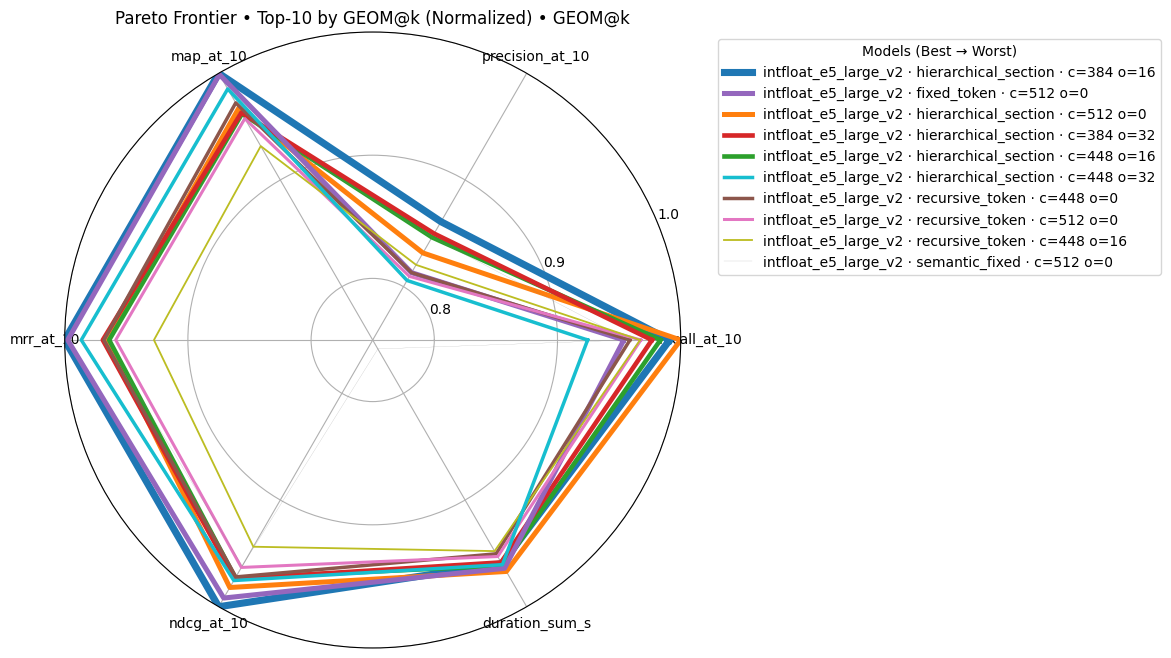

✅ Saved: ../artifacts/fig_radar_pareto_top10.png


In [4]:
# ✅ Radar plot for top 10 configs
# metrics_to_plot = [
#     "recall_at_1", "recall_at_3","recall_at_10", "recall_at_100",
#     "precision_at_1", "precision_at_3","precision_at_10", "precision_at_100",
#     "map_at_1", "map_at_3","map_at_10", "map_at_100",
#     "mrr_at_1", "mrr_at_3","mrr_at_10", "mrr_at_100",
#     "ndcg_at_1", "ndcg_at_3","ndcg_at_10", "ndcg_at_100",
#     "duration_sum_s"
# ]

metrics_to_plot = [
    "recall_at_10",
    "precision_at_10",
    "map_at_10",
    "mrr_at_10",
    "ndcg_at_10",
    "duration_sum_s"
]

lower_is_better = {"duration_sum_s": True, "cost_norm": True}  
primary_metric = "GEOM@k"   # or "ndcg_at_10" if GEOM@k is not present

plot_radar_on_pareto(
    df=df, 
    pareto_df=top_df,     # 👈 Pass top 10 from 3D code here
    metrics_to_plot=metrics_to_plot, 
    lower_is_better=lower_is_better, 
    primary_metric=primary_metric, 
    top_n=10            # how many to show on radar (4 polygons)
)
